In [1]:
!mkdir data
%cd data

!wget https://raw.githubusercontent.com/traffic-signal-control/sample-code/master/data/hangzhou_1x1_kn-hz_18041608_1h/roadnet.json
!wget https://raw.githubusercontent.com/traffic-signal-control/sample-code/master/data/hangzhou_1x1_kn-hz_18041608_1h/flow.json
!wget https://raw.githubusercontent.com/traffic-signal-control/sample-code/master/data/hangzhou_1x1_kn-hz_18041608_1h/config.json

/content/data
--2026-03-15 17:09:58--  https://raw.githubusercontent.com/traffic-signal-control/sample-code/master/data/hangzhou_1x1_kn-hz_18041608_1h/roadnet.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30287 (30K) [text/plain]
Saving to: ‘roadnet.json’

roadnet.json        100%[===================>]  29.58K  --.-KB/s    in 0.001s  

2026-03-15 17:09:58 (23.4 MB/s) - ‘roadnet.json’ saved [30287/30287]

--2026-03-15 17:09:58--  https://raw.githubusercontent.com/traffic-signal-control/sample-code/master/data/hangzhou_1x1_kn-hz_18041608_1h/flow.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|

In [2]:
import os

print(os.listdir('/content/data'))

['roadnet.json', 'flow.json']


In [5]:
config = {
    "interval": 1,
    "seed": 0,
    "dir": "/content/data/",
    "roadnetFile": "roadnet.json",
    "flowFile": "flow.json",
    "rlTrafficLight": True,
    "saveReplay": False,
    "laneChange": False
}

import json
with open("/content/data/config.json", "w") as f:
    json.dump(config, f, indent=4)

print("config.json created")

config.json created


In [6]:
!ls /content/data

config.json  flow.json	roadnet.json


In [18]:
import json

with open('/content/data/roadnet.json') as f:
    roadnet = json.load(f)

with open('/content/data/flow.json') as f:
    flow = json.load(f)

print("Vehicles in dataset:", len(flow))

Vehicles in dataset: 743


In [19]:
start_times = [v['startTime'] for v in flow]

print("First 10 vehicle start times:")
print(start_times[:10])

First 10 vehicle start times:
[5, 38, 40, 65, 67, 69, 69, 71, 73, 73]


In [20]:
import collections

traffic = collections.Counter(start_times)

for t in range(10):
    print("Time", t, "Vehicles:", traffic[t])

Time 0 Vehicles: 0
Time 1 Vehicles: 0
Time 2 Vehicles: 0
Time 3 Vehicles: 0
Time 4 Vehicles: 0
Time 5 Vehicles: 1
Time 6 Vehicles: 0
Time 7 Vehicles: 0
Time 8 Vehicles: 0
Time 9 Vehicles: 0


In [21]:
for time in range(60):

    vehicles = traffic[time]

    if vehicles > 5:
        signal = "GREEN_LONG"
    else:
        signal = "NORMAL"

    print(time, signal)

0 NORMAL
1 NORMAL
2 NORMAL
3 NORMAL
4 NORMAL
5 NORMAL
6 NORMAL
7 NORMAL
8 NORMAL
9 NORMAL
10 NORMAL
11 NORMAL
12 NORMAL
13 NORMAL
14 NORMAL
15 NORMAL
16 NORMAL
17 NORMAL
18 NORMAL
19 NORMAL
20 NORMAL
21 NORMAL
22 NORMAL
23 NORMAL
24 NORMAL
25 NORMAL
26 NORMAL
27 NORMAL
28 NORMAL
29 NORMAL
30 NORMAL
31 NORMAL
32 NORMAL
33 NORMAL
34 NORMAL
35 NORMAL
36 NORMAL
37 NORMAL
38 NORMAL
39 NORMAL
40 NORMAL
41 NORMAL
42 NORMAL
43 NORMAL
44 NORMAL
45 NORMAL
46 NORMAL
47 NORMAL
48 NORMAL
49 NORMAL
50 NORMAL
51 NORMAL
52 NORMAL
53 NORMAL
54 NORMAL
55 NORMAL
56 NORMAL
57 NORMAL
58 NORMAL
59 NORMAL


In [22]:
!pip install stable-baselines3 gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 7.1 MB/s eta 0:00:00


In [32]:
import json
import numpy as np
import collections

with open('/content/data/flow.json') as f:
    flow = json.load(f)

# Extract start times
start_times = [v["startTime"] for v in flow]

# Shift times so simulation starts at 0
min_time = min(start_times)
start_times = [t - min_time for t in start_times]

# Count vehicles per timestep
traffic = collections.Counter(start_times)

print("Total vehicles:", len(start_times))

print("First traffic arrivals:")
for i in range(200):
    if traffic.get(i,0) > 0:
        print(i, traffic[i])

Total vehicles: 743
First traffic arrivals:
0 1
33 1
35 1
60 1
62 1
64 2
66 1
68 2
72 1
73 1
76 1
79 1
80 2
88 1
92 2
98 1
103 1
139 1
149 1
163 1
168 1
173 1
180 1
184 1


In [37]:
import json

with open('/content/data/roadnet.json') as f:
    roadnet = json.load(f)

print("Intersections:", len(roadnet["intersections"]))
print("Roads:", len(roadnet["roads"]))

Intersections: 5
Roads: 8


In [38]:
incoming_lanes = []

for road in roadnet["roads"]:
    for lane in road["lanes"]:
        incoming_lanes.append(road["id"])

print("Total lanes:", len(incoming_lanes))

Total lanes: 16


In [39]:
class TrafficEnv(gym.Env):

    def __init__(self):
        super().__init__()

        self.action_space = spaces.Discrete(2)

        # queue per direction
        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(4,),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):

        self.time = 0
        self.queue = np.zeros(4)

        return self.queue.astype(np.float32), {}

    def step(self, action):

        arrivals = sum(traffic.get(self.time + i, 0) for i in range(10))

        incoming = np.random.multinomial(arrivals,[0.25,0.25,0.25,0.25])

        self.queue += incoming

        # signal control
        if action == 0:
            self.queue[0] = max(0,self.queue[0]-4)
            self.queue[1] = max(0,self.queue[1]-4)

        if action == 1:
            self.queue[2] = max(0,self.queue[2]-4)
            self.queue[3] = max(0,self.queue[3]-4)

        reward = -np.sum(self.queue)

        self.time += 10

        done = self.time > 3600

        return self.queue.astype(np.float32), reward, done, False, {}

In [40]:
env = TrafficEnv()

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.0003,
    n_steps=512,
    batch_size=64
)

model.learn(total_timesteps=30000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 361      |
|    ep_rew_mean     | -805     |
| time/              |          |
|    fps             | 750      |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 361         |
|    ep_rew_mean          | -805        |
| time/                   |             |
|    fps                  | 595         |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.008253163 |
|    clip_fraction        | 0.0467      |
|    clip_range           | 0.2         |
|    entropy_loss  

In [41]:
obs,_ = env.reset()

queues=[]

for step in range(200):

    action,_ = model.predict(obs)

    obs,reward,done,_,_ = env.step(action)

    queues.append(sum(obs))

    if done:
        break

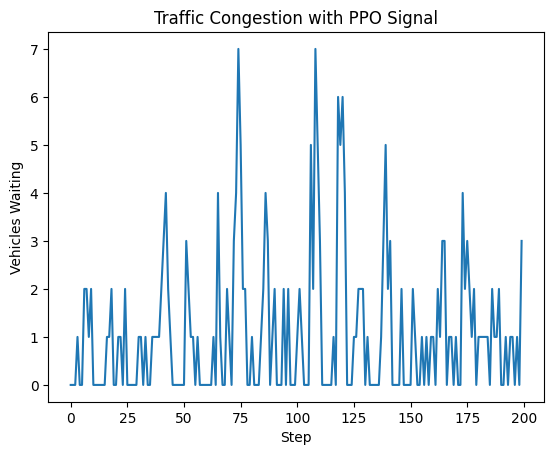

In [42]:
import matplotlib.pyplot as plt

plt.plot(queues)

plt.title("Traffic Congestion with PPO Signal")

plt.xlabel("Step")

plt.ylabel("Vehicles Waiting")

plt.show()

In [43]:
obs,_ = env.reset()

fixed_queue=[]

for step in range(200):

    action = step % 2

    obs,reward,done,_,_ = env.step(action)

    fixed_queue.append(sum(obs))

    if done:
        break

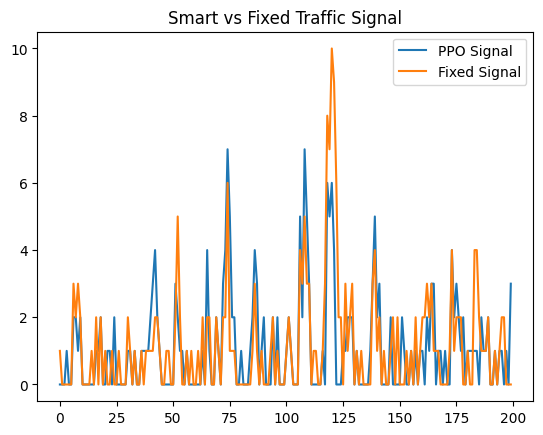

In [44]:
plt.plot(queues,label="PPO Signal")

plt.plot(fixed_queue,label="Fixed Signal")

plt.legend()

plt.title("Smart vs Fixed Traffic Signal")

plt.show()

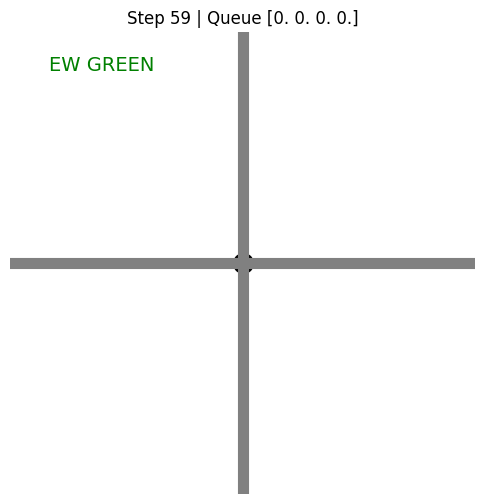

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time

obs,_ = env.reset()

# positions of cars
north=[]
south=[]
east=[]
west=[]

for step in range(60):

    action,_ = model.predict(obs)
    obs,reward,done,_,_ = env.step(action)

    clear_output(wait=True)

    # update car queues
    north = list(range(int(obs[0])))
    south = list(range(int(obs[1])))
    east  = list(range(int(obs[2])))
    west  = list(range(int(obs[3])))

    plt.figure(figsize=(6,6))

    # draw roads
    plt.plot([-6,6],[0,0],linewidth=8,color="gray")
    plt.plot([0,0],[-6,6],linewidth=8,color="gray")

    # draw intersection
    plt.scatter(0,0,s=200,color="black")

    # draw cars
    for i in north:
        plt.scatter(0,5-i*0.5,color="blue",s=80)

    for i in south:
        plt.scatter(0,-5+i*0.5,color="blue",s=80)

    for i in east:
        plt.scatter(5-i*0.5,0,color="red",s=80)

    for i in west:
        plt.scatter(-5+i*0.5,0,color="red",s=80)

    # signal indicator
    if action == 0:
        plt.text(-5,5,"NS GREEN",fontsize=14,color="green")
    else:
        plt.text(-5,5,"EW GREEN",fontsize=14,color="green")

    plt.xlim(-6,6)
    plt.ylim(-6,6)
    plt.axis("off")

    plt.title(f"Step {step} | Queue {obs}")

    plt.show()

    time.sleep(0.4)